# Notebook 01 — Exploratory Data Analysis of PrimeVul

This notebook explores the **PrimeVul** dataset that our vulnerability detector learns from. Before building any model, we must understand the data: its size, its structure, and — crucially — its **severe class imbalance**.

We analyse **all three official splits** (`train`, `valid`, `test`) so we can also verify that they are **distributionally consistent** (a model tuned on `valid` should generalize to `test`).

**What we look at:**
1. Dataset schema — what fields each record contains
2. Split sizes and the vulnerable/safe class balance
3. Function-length distributions (drives preprocessing size limits)
4. Which vulnerability types (CWEs) dominate
5. Which software projects the code comes from
6. A cross-split consistency check

All reading is done through the project's own `DataLoader` (`source/preprocessing/.../data_loader.py`), which streams the JSONL files record by record.

In [8]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from source.preprocessing.data_preprocessing.data_loading.data_loader import DataLoader

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

SPLITS = {
    "train": os.path.join(PROJECT_ROOT, "data", "primevul_train.jsonl"),
    "valid": os.path.join(PROJECT_ROOT, "data", "primevul_valid.jsonl"),
    "test":  os.path.join(PROJECT_ROOT, "data", "primevul_test.jsonl")
}

loader = DataLoader()
print("Splits to analyse:")
for name, path in SPLITS.items():
    size_mb = os.path.getsize(path) / 1e6
    print(f"  {name:6s} {path}  ({size_mb:.0f} MB)")

Splits to analyse:
  train  /Users/I768838/Desktop/Vuln47/data/primevul_train.jsonl  (471 MB)
  valid  /Users/I768838/Desktop/Vuln47/data/primevul_valid.jsonl  (64 MB)
  test   /Users/I768838/Desktop/Vuln47/data/primevul_test.jsonl  (66 MB)


## 1. Dataset Schema — What Does One Record Look Like?

PrimeVul is stored as **JSONL** (one JSON object per line). Each object is a single C/C++ function plus its metadata. Let's inspect the fields of one record.

In [9]:
# grab the first vulnerable record from valid (small, fast) to show a meaningful example
example = None
for rec in loader.load(SPLITS["valid"]):
    if rec.get("target") == 1:
        example = rec
        break

print("Fields present in a record:")
for k, v in example.items():
    preview = str(v).replace("\n", " ")
    preview = preview[:80] + ("…" if len(preview) > 80 else "")
    print(f"  {k:12s}: {preview}")

print("\nThe two fields we actually use for modelling:")
print(f"  func   -> the raw C/C++ source (our model input)")
print(f"  target -> label: 1 = vulnerable, 0 = safe (what we predict)")
print(f"\nExtra metadata (cwe, cve, project) is used only for EDA, not training.")

Fields present in a record:
  idx         : 194999
  project     : hhvm
  commit_id   : 08193b7f0cd3910256e00d599f0f3eb2519c44ca
  project_url : https://github.com/facebook/hhvm
  commit_url  : https://github.com/facebook/hhvm/commit/08193b7f0cd3910256e00d599f0f3eb2519c44ca
  commit_message: security fixes  https://hhvm.com/blog/2021/02/25/security-update.html
  target      : 1
  func        : String preg_quote(const String& str,                   const String& delimiter /…
  func_hash   : 238223164532786533215583452209843695586
  file_name   : preg.cpp
  file_hash   : 285507481464794574944910815142691250961
  cwe         : ['CWE-190']
  cve         : CVE-2020-1918
  cve_desc    : In-memory file operations (ie: using fopen on a data URI) did not properly restr…
  nvd_url     : https://nvd.nist.gov/vuln/detail/CVE-2020-1918

The two fields we actually use for modelling:
  func   -> the raw C/C++ source (our model input)
  target -> label: 1 = vulnerable, 0 = safe (what we predict)

Extr

## 2. Aggregating Every Split

We stream each split once, collecting: the class counts, function lengths (in characters), CWE frequencies (for vulnerable functions), and project frequencies. The `train` split is ~470 MB, so this cell takes a little while — it reads ~225k functions in total.

In [10]:
def analyze_split(path):
    lengths, labels = [], []
    cwe_counter, project_counter = Counter(), Counter()
    for rec in loader.load(path):
        target = int(rec.get("target", 0))
        labels.append(target)
        lengths.append(len(rec.get("func", "")))
        project_counter[rec.get("project", "?")] += 1
        if target == 1:
            for c in rec.get("cwe") or []:
                cwe_counter[c] += 1
    labels = np.array(labels)
    lengths = np.array(lengths)
    return {
        "lengths": lengths,
        "labels": labels,
        "cwe": cwe_counter,
        "projects": project_counter
    }

# read all three splits (heavy: reads the full train file)
raw = {name: analyze_split(path) for name, path in SPLITS.items()}

# build a tidy summary table
rows = []
for name, d in raw.items():
    n = len(d["labels"])
    n_vuln = int(d["labels"].sum())
    n_safe = n - n_vuln
    rows.append({
        "split": name,
        "functions": n,
        "vulnerable": n_vuln,
        "safe": n_safe,
        "% vulnerable": round(100 * n_vuln / n, 2),
        "imbalance (safe:vuln)": f"{n_safe / n_vuln:.1f} : 1",
        "median len": int(np.median(d["lengths"])),
        "mean len": int(d["lengths"].mean()),
        "p99 len": int(np.percentile(d["lengths"], 99)),
        "max len": int(d["lengths"].max()),
        "# projects": len(d["projects"])
    })

summary = pd.DataFrame(rows).set_index("split")
summary

,functions,vulnerable,safe,% vulnerable,imbalance (safe:vuln),median len,mean len,p99 len,max len,# projects
split,,,,,,,,,,
train,175797,4862,170935,2.77,35.2 : 1,480,1296,13321,484356,631
valid,23948,593,23355,2.48,39.4 : 1,503,1232,11655,106112,217
test,24788,549,24239,2.21,44.2 : 1,490,1288,13242,137677,220


## 3. The Class Imbalance — The Defining Feature of This Dataset

The summary table already tells the most important story: only **~2.2–2.8%** of functions are vulnerable. Let's visualize this, because it dictates every downstream decision (loss weighting, choice of metrics). The plot below shows the safe-vs-vulnerable split for each dataset partition.

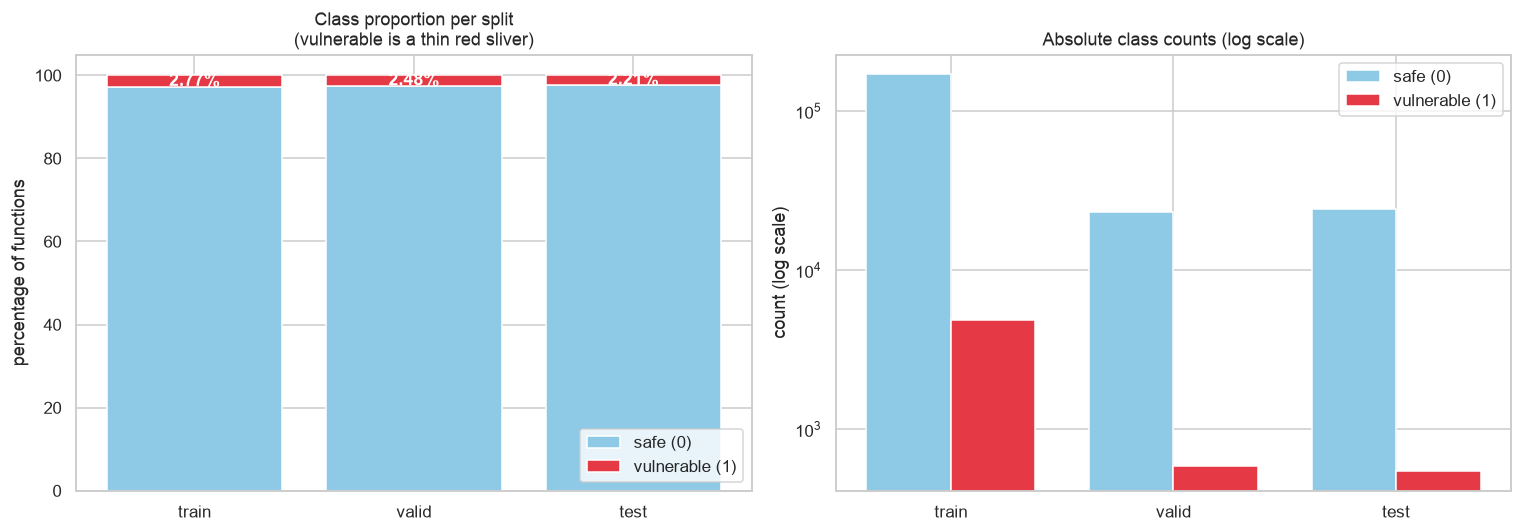

Key takeaway: a naive 'always safe' classifier would score ~97% accuracy
while catching 0 vulnerabilities. This is why we use F1/Precision/Recall/PR-AUC.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) stacked proportion bar per split
names = list(raw.keys())
safe_pct = [100 * (1 - raw[n]["labels"].mean()) for n in names]
vuln_pct = [100 * raw[n]["labels"].mean() for n in names]

axes[0].bar(names, safe_pct, label="safe (0)", color="#8ecae6")
axes[0].bar(names, vuln_pct, bottom=safe_pct, label="vulnerable (1)", color="#e63946")
for i, n in enumerate(names):
    axes[0].text(i, safe_pct[i] + vuln_pct[i] / 2, f"{vuln_pct[i]:.2f}%",
        ha="center", va="center", color="white", fontweight="bold")
axes[0].set_ylabel("percentage of functions")
axes[0].set_title("Class proportion per split\n(vulnerable is a thin red sliver)")
axes[0].legend(loc="lower right")

# (b) absolute counts on a log scale to make the rare class visible
x = np.arange(len(names))
w = 0.38
axes[1].bar(x - w / 2, [raw[n]["labels"].size - raw[n]["labels"].sum() for n in names], w, label="safe (0)", color="#8ecae6")
axes[1].bar(x + w / 2, [raw[n]["labels"].sum() for n in names], w, label="vulnerable (1)", color="#e63946")
axes[1].set_yscale("log")
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel("count (log scale)")
axes[1].set_title("Absolute class counts (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Key takeaway: a naive 'always safe' classifier would score ~97% accuracy")
print("while catching 0 vulnerabilities. This is why we use F1/Precision/Recall/PR-AUC.")

## 4. Function-Length Distribution

Function length (in characters) matters because our preprocessing caps very large functions (`MAX_CODE_BYTES = 30,000`, `MAX_NODES = 2,000` in `code_graph_config.py`) to keep parsing and graphs tractable. The distribution is **extremely right-skewed** — most functions are short, but a few are enormous (up to ~484k chars). We plot on a log-x scale and mark the median and the p99, then quantify how many functions the cap actually affects.

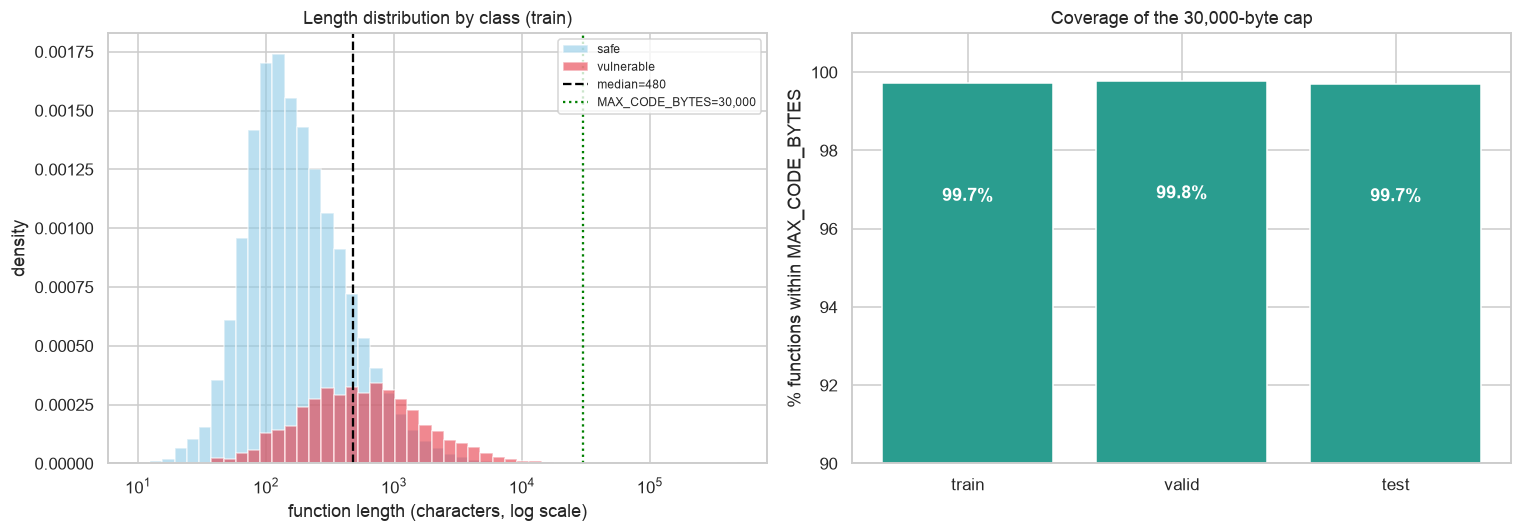

train :   504 functions exceed the cap (0.29%)
valid :    53 functions exceed the cap (0.22%)
test  :    73 functions exceed the cap (0.29%)


In [12]:
from source.preprocessing.data_preprocessing.data_representation.data_graph_representation.code_graph_config import (
    MAX_CODE_BYTES,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) length histogram on log-x, split by class, using the train split
train_lengths = raw["train"]["lengths"]
train_labels = raw["train"]["labels"]
bins = np.logspace(1, np.log10(train_lengths.max()), 50)
axes[0].hist(train_lengths[train_labels == 0], bins=bins, alpha=0.6, 
    label="safe", color="#8ecae6", density=True)
axes[0].hist(train_lengths[train_labels == 1], bins=bins, alpha=0.6,
    label="vulnerable", color="#e63946", density=True)
axes[0].axvline(np.median(train_lengths), color="black", ls="--",
    label=f"median={int(np.median(train_lengths))}")
axes[0].axvline(MAX_CODE_BYTES, color="green", ls=":",
    label=f"MAX_CODE_BYTES={MAX_CODE_BYTES:,}")
axes[0].set_xscale("log")
axes[0].set_xlabel("function length (characters, log scale)")
axes[0].set_ylabel("density")
axes[0].set_title("Length distribution by class (train)")
axes[0].legend(fontsize=8)

# (b) how much data does the size cap discard, per split?
kept = []
for n in names:
    L = raw[n]["lengths"]
    kept.append(100 * (L <= MAX_CODE_BYTES).mean())
axes[1].bar(names, kept, color="#2a9d8f")
for i, v in enumerate(kept):
    axes[1].text(i, v - 3, f"{v:.1f}%", ha="center", color="white", fontweight="bold")
axes[1].set_ylim(90, 101)
axes[1].set_ylabel("% functions within MAX_CODE_BYTES")
axes[1].set_title(f"Coverage of the {MAX_CODE_BYTES:,}-byte cap")

plt.tight_layout()
plt.show()

for n in names:
    L = raw[n]["lengths"]
    print(f"{n:6s}: {(L > MAX_CODE_BYTES).sum():>5d} functions exceed the cap "
        f"({100*(L>MAX_CODE_BYTES).mean():.2f}%)")

## 5. What Kinds of Vulnerabilities? (CWE Distribution)

Each vulnerable function is tagged with one or more **CWE** identifiers (Common Weakness Enumeration — a standard taxonomy of software weaknesses). Looking at the most frequent CWEs tells us what our model will mostly be learning to detect. Memory-safety issues dominate, which is expected for C/C++.

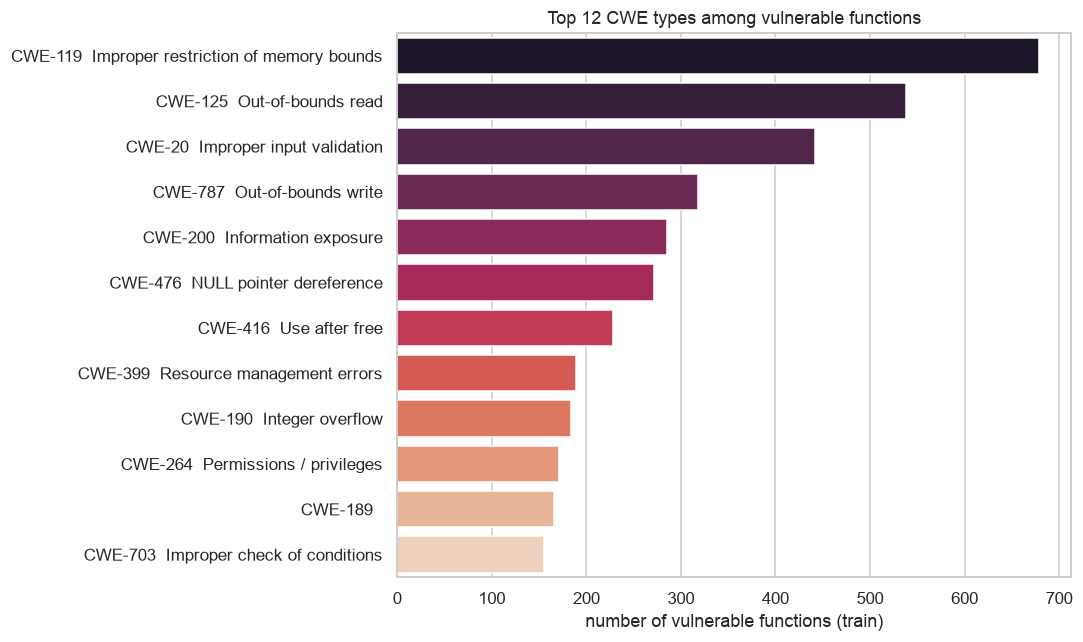

In [13]:
# human-readable names for the CWEs we expect to see most
CWE_NAMES = {
    "CWE-119": "Improper restriction of memory bounds",
    "CWE-125": "Out-of-bounds read",
    "CWE-787": "Out-of-bounds write",
    "CWE-20":  "Improper input validation",
    "CWE-200": "Information exposure",
    "CWE-476": "NULL pointer dereference",
    "CWE-416": "Use after free",
    "CWE-399": "Resource management errors",
    "CWE-190": "Integer overflow",
    "CWE-264": "Permissions / privileges",
    "CWE-703": "Improper check of conditions",
    "CWE-369": "Divide by zero",
    "CWE-401": "Memory leak"
}

train_cwe = raw["train"]["cwe"].most_common(12)
labels_cwe = [f"{c}  {CWE_NAMES.get(c, '')}" for c, _ in train_cwe]
counts_cwe = [n for _, n in train_cwe]

plt.figure(figsize=(10, 6))
sns.barplot(x=counts_cwe, y=labels_cwe, palette="rocket", hue=labels_cwe, legend=False)
plt.xlabel("number of vulnerable functions (train)")
plt.title("Top 12 CWE types among vulnerable functions")
plt.tight_layout()
plt.show()

## 6. Source Projects & Cross-Split Consistency

Finally, two checks. **(a)** Which open-source projects contribute the most functions — the Linux kernel dominates, which shapes what "typical" C code looks like to the model. **(b)** A **consistency check**: the vulnerable-rate should be similar across `train`/`valid`/`test`, otherwise tuning on one split would not transfer to another. PrimeVul's splits are consistent (~2.2–2.8%), which validates our train→valid→test protocol.

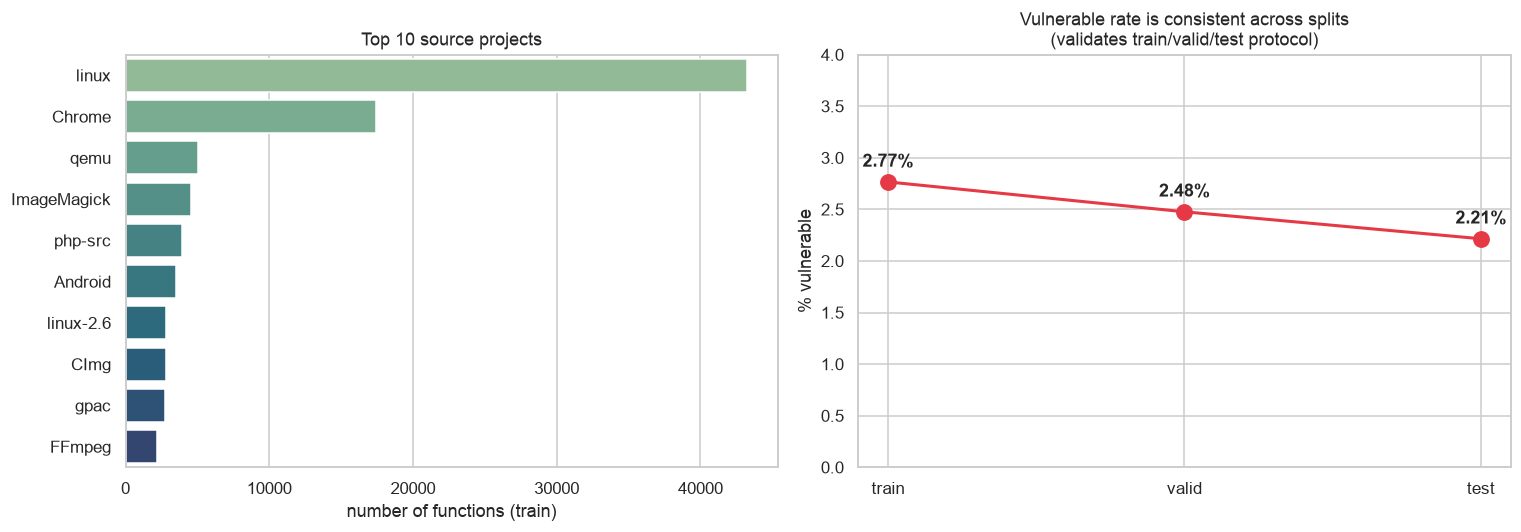

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) top projects in train
top_proj = raw["train"]["projects"].most_common(10)
sns.barplot(x=[c for _, c in top_proj], y=[p for p, _ in top_proj],
    palette="crest", hue=[p for p, _ in top_proj], legend=False, ax=axes[0])
axes[0].set_xlabel("number of functions (train)")
axes[0].set_title("Top 10 source projects")

# (b) vulnerable rate consistency across splits
vuln_rate = [100 * raw[n]["labels"].mean() for n in names]
axes[1].plot(names, vuln_rate, "o-", color="#e63946", markersize=10, linewidth=2)
for i, v in enumerate(vuln_rate):
    axes[1].annotate(f"{v:.2f}%", (i, v), textcoords="offset points",
        xytext=(0, 10), ha="center", fontweight="bold")
axes[1].set_ylim(0, 4)
axes[1].set_ylabel("% vulnerable")
axes[1].set_title("Vulnerable rate is consistent across splits\n(validates train/valid/test protocol)")

plt.tight_layout()
plt.show()

## 7. Summary of Findings

| Observation | Consequence for the project |
|---|---|
| **~2.2–2.8% vulnerable** across all splits | Must use class-weighted loss + F1/Precision/Recall/PR-AUC, never accuracy |
| **Consistent rate across splits** | The train/valid/test protocol is valid; tuning transfers |
| **Length is heavily right-skewed** (median ~480 chars, max ~484k) | A size cap is needed; it discards <1% of functions |
| **Memory-safety CWEs dominate** (out-of-bounds read/write, use-after-free) | Motivates the hand-crafted "dangerous function" token feature |
| **Linux kernel dominates** the source projects | Model sees mostly kernel-style C; a caveat for generalization |

These facts directly justify the preprocessing choices in **Notebook 02** and the training/evaluation strategy in **Notebooks 03–04**.